In [ ]:
!git clone https://github.com/YadnikBangale/Shark-tank-India-Decision-Modeling.git

Cloning into 'Shark-tank-India-Decision-Modeling'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 119 (delta 5), reused 7 (delta 1), pack-reused 104 (from 1)
Receiving objects: 100% (119/119), 517.16 KiB | 15.21 MiB/s, done.
Resolving deltas: 100% (50/50), done.


In [ ]:
import os
os.chdir("Shark-tank-India-Decision-Modeling")

In [ ]:
import sys
sys.path.append('./scripts')

In [ ]:
from preprocessing_sample import run_preprocessing

In [ ]:
import pandas as pd

df = pd.read_csv("Shark Tank India.csv")

X_scaled, y_reg, y_cls, y_shark = run_preprocessing(df)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [ ]:
X_scaled['Total Deal Amount'] = y_reg
X_scaled['Accepted Offer'] = y_cls

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style = "whitegrid")

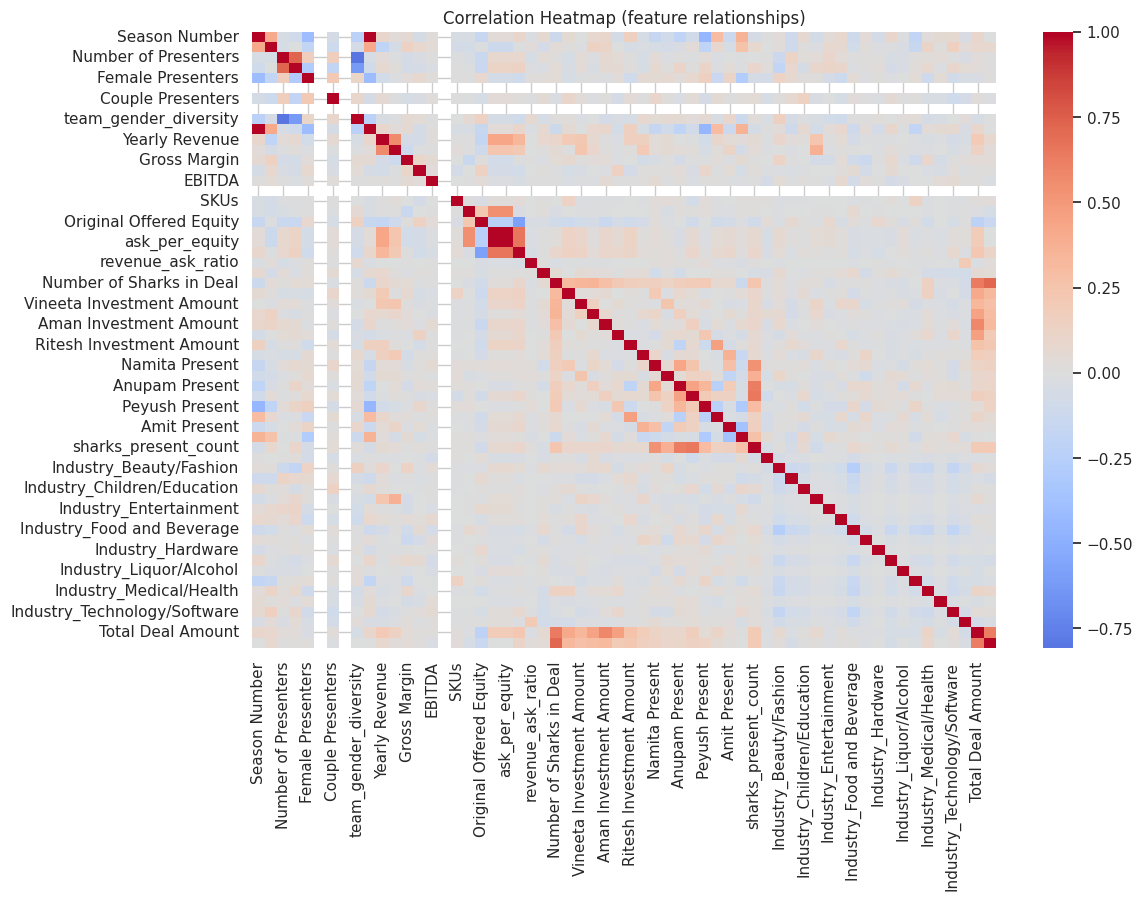

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(X_scaled.corr(), cmap = 'coolwarm', center = 0)
plt.title("Correlation Heatmap (feature relationships)")
plt.show()
## This shows relationships between features and helps identify important predictors.

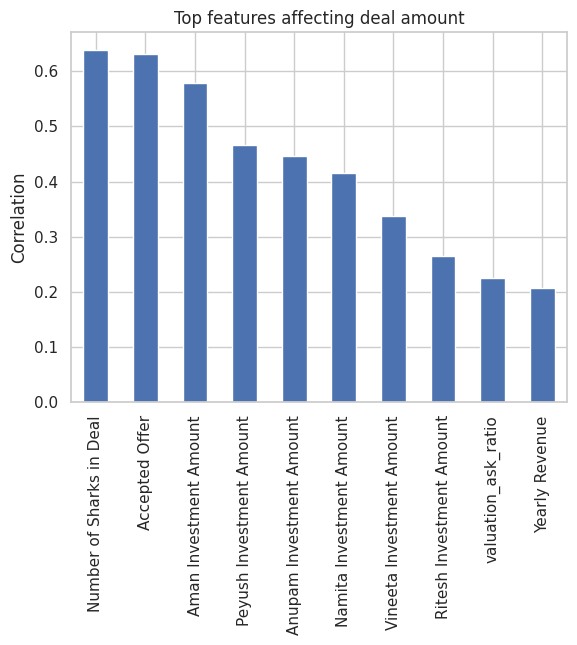

In [ ]:
## These features have the strongest influence on investment amount.
corr_target = X_scaled.corr()['Total Deal Amount'].sort_values(ascending = False)
corr_target.drop('Total Deal Amount').head(10).plot(kind='bar')
plt.title('Top features affecting deal amount')
plt.ylabel("Correlation")
plt.show()

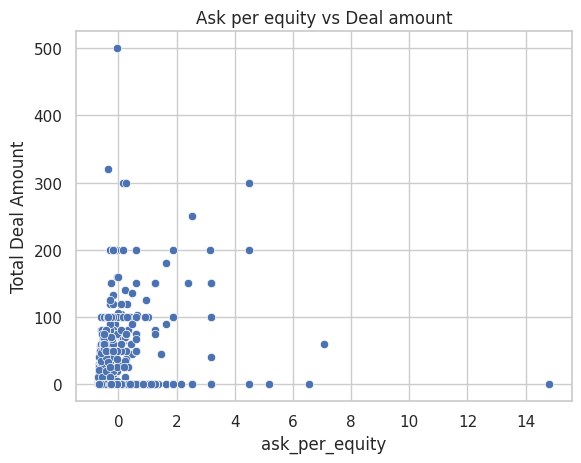

In [ ]:
## Higher ask per equity tends to influence deal size
sns.scatterplot(
    x = 'ask_per_equity',
    y = 'Total Deal Amount',
    data = X_scaled
)
plt.title("Ask per equity vs Deal amount")
plt.show()

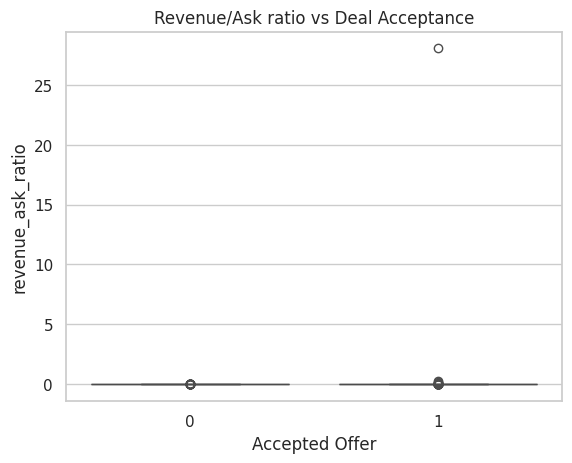

In [ ]:
## Higher revenue relative to ask increases chances of acceptance.
sns.boxplot(
    x = 'Accepted Offer',
    y = 'revenue_ask_ratio',
    data = X_scaled
)
plt.title("Revenue/Ask ratio vs Deal Acceptance")
plt.show()

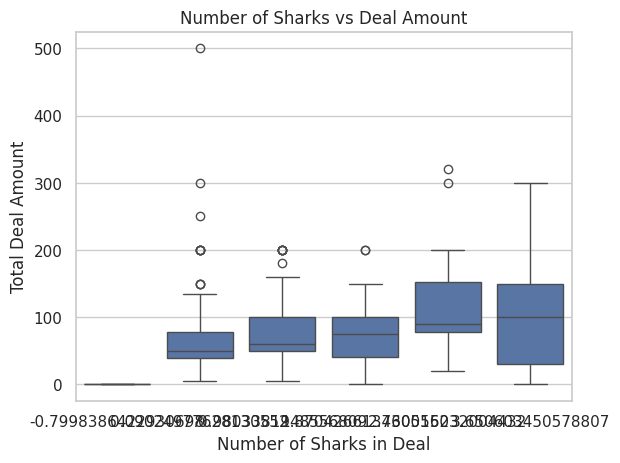

In [ ]:
## More sharks generally lead to larger deals.
sns.boxplot(
    x = 'Number of Sharks in Deal',
    y = 'Total Deal Amount',
    data = X_scaled
)
plt.title("Number of Sharks vs Deal Amount")
plt.show()

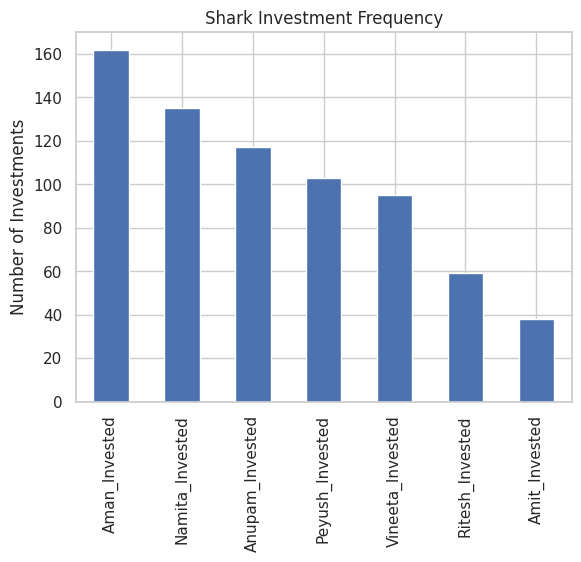

In [ ]:
## which shark invests more frequently ?
y_shark.sum().sort_values(ascending = False).plot(kind='bar')
plt.title("Shark Investment Frequency")
plt.ylabel("Number of Investments")
plt.show()

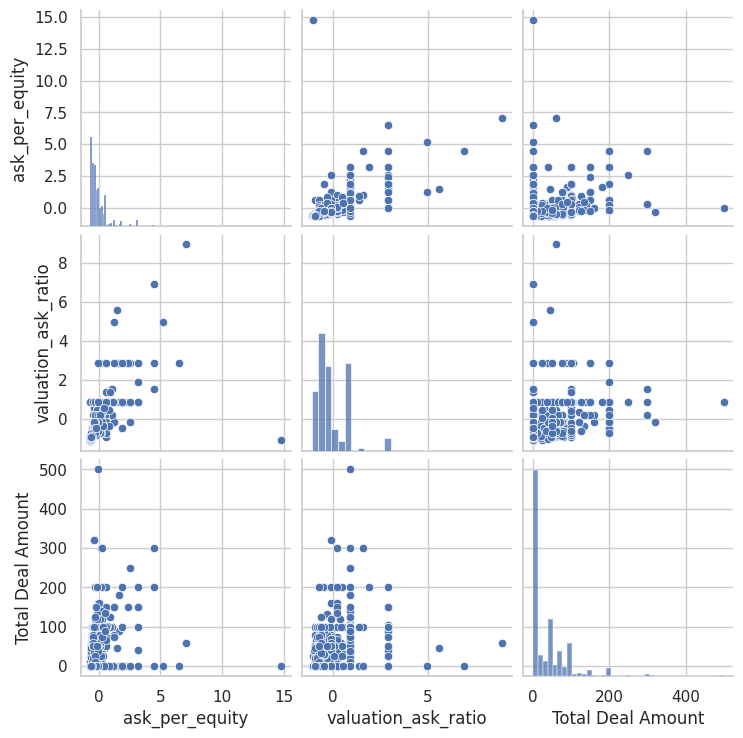

In [ ]:
sns.pairplot(X_scaled[['ask_per_equity','valuation_ask_ratio','Total Deal Amount']])
plt.show()

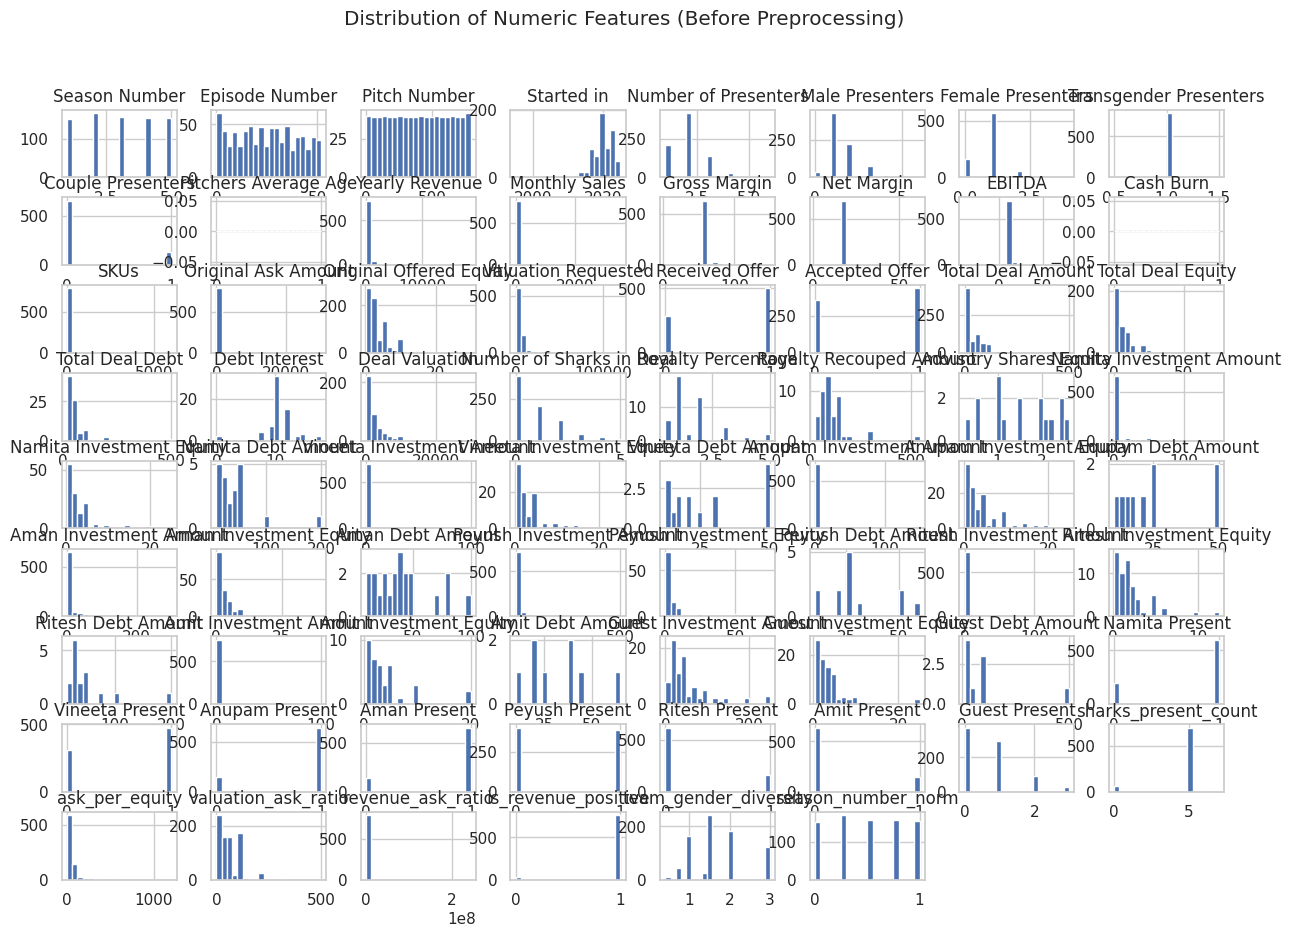

In [ ]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

df[numeric_cols].hist(figsize=(15,10), bins=20)
plt.suptitle("Distribution of Numeric Features (Before Preprocessing)")
plt.show()

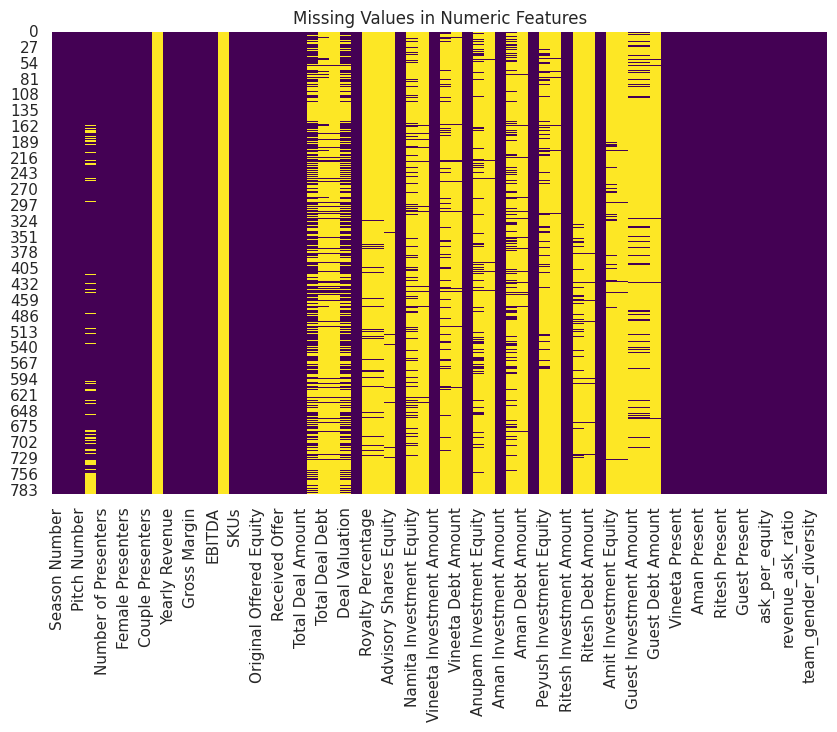

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values in Numeric Features")
plt.show()

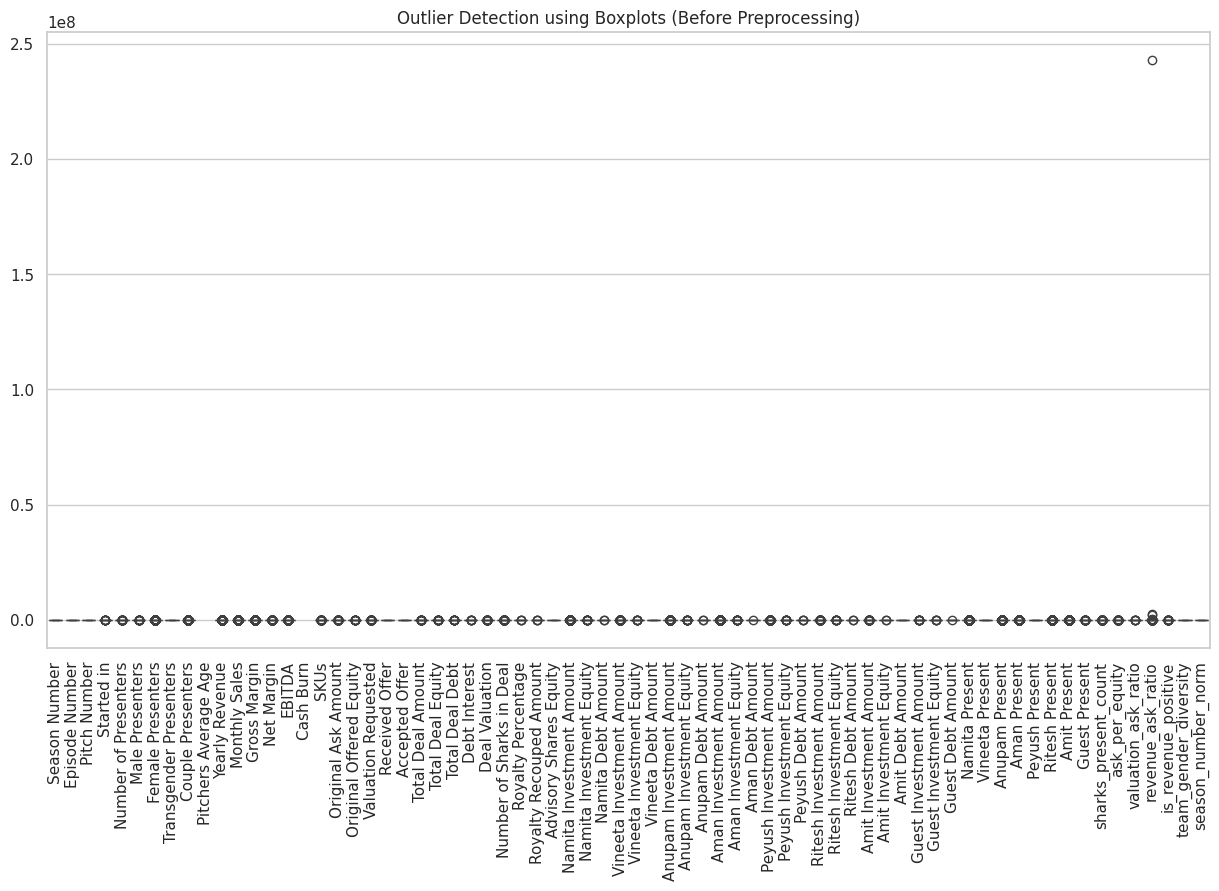

In [ ]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=90)
plt.title("Outlier Detection using Boxplots (Before Preprocessing)")
plt.show()

In [30]:
max_vals = df[numeric_cols].max().sort_values(ascending=False)
print(max_vals.head(10))

revenue_ask_ratio      243000000.0
Valuation Requested       120000.0
Original Ask Amount        30000.0
Deal Valuation             30000.0
Yearly Revenue             18700.0
SKUs                        6000.0
Monthly Sales               3500.0
Started in                  2025.0
ask_per_equity              1200.0
Pitch Number                 787.0
dtype: float64


In [31]:
df[df['revenue_ask_ratio'] == df['revenue_ask_ratio'].max()]

,Season Number,Startup Name,Episode Number,Pitch Number,Season Start,Season End,Original Air Date,Episode Title,Anchor,Industry,...,Ritesh Present,Amit Present,Guest Present,sharks_present_count,ask_per_equity,valuation_ask_ratio,revenue_ask_ratio,is_revenue_positive,team_gender_diversity,season_number_norm
243,2,DhruvVidyut,30,244,2-Jan-23,10-Mar-23,10-Feb-23,Changing India,Rahul Dua,Vehicles/Electrical Vehicles,...,0.0,0.0,0.0,5.0,0.000002,0.0,243000000.0,1,3.0,0.25


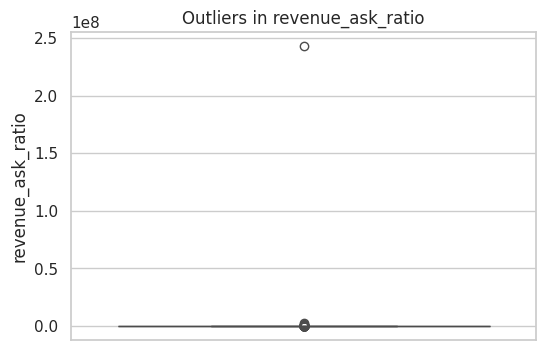

In [32]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['revenue_ask_ratio'])
plt.title("Outliers in revenue_ask_ratio")
plt.show()

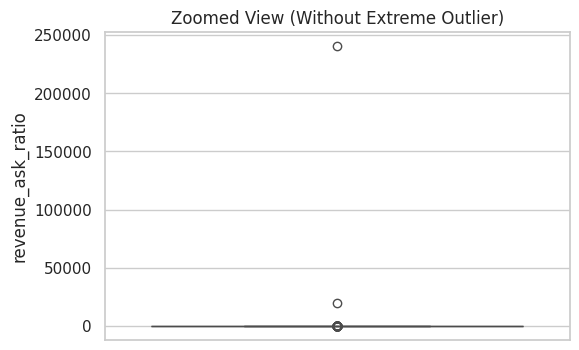

In [33]:
filtered = df[df['revenue_ask_ratio'] < 1e6]

plt.figure(figsize=(6,4))
sns.boxplot(y=filtered['revenue_ask_ratio'])
plt.title("Zoomed View (Without Extreme Outlier)")
plt.show()

In [34]:
df['revenue_ask_ratio'].describe()

,revenue_ask_ratio
count,7.890000e+02
mean,3.139347e+05
std,8.651546e+06
min,0.000000e+00
25%,2.025000e+00
50%,3.240000e+00
75%,6.075000e+00
max,2.430000e+08


In [ ]:
df.columns

Index(['Season Number', 'Startup Name', 'Episode Number', 'Pitch Number',
       'Season Start', 'Season End', 'Original Air Date', 'Episode Title',
       'Anchor', 'Industry', 'Business Description', 'Company Website',
       'Started in', 'Number of Presenters', 'Male Presenters',
       'Female Presenters', 'Transgender Presenters', 'Couple Presenters',
       'Pitchers Average Age', 'Pitchers City', 'Pitchers State',
       'Yearly Revenue', 'Monthly Sales', 'Gross Margin', 'Net Margin',
       'EBITDA', 'Cash Burn', 'SKUs', 'Has Patents', 'Bootstrapped',
       'Part of Match off', 'Original Ask Amount', 'Original Offered Equity',
       'Valuation Requested', 'Received Offer', 'Accepted Offer',
       'Total Deal Amount', 'Total Deal Equity', 'Total Deal Debt',
       'Debt Interest', 'Deal Valuation', 'Number of Sharks in Deal',
       'Deal Has Conditions', 'Royalty Percentage', 'Royalty Recouped Amount',
       'Advisory Shares Equity', 'Namita Investment Amount',
       'Nam

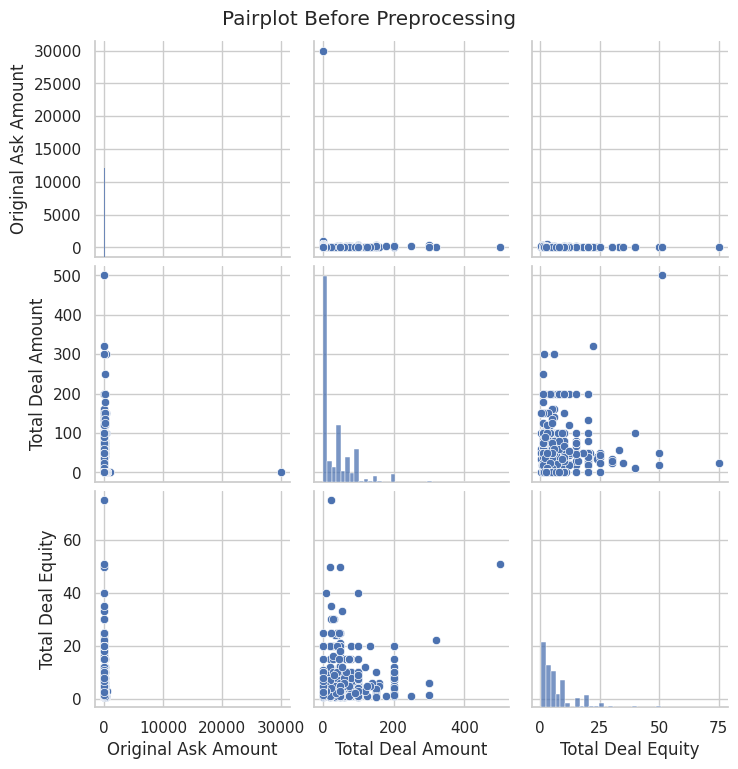

In [ ]:
sns.pairplot(df[['Original Ask Amount',
                 'Total Deal Amount',
                 'Total Deal Equity']])

plt.suptitle("Pairplot Before Preprocessing", y=1.02)
plt.show()

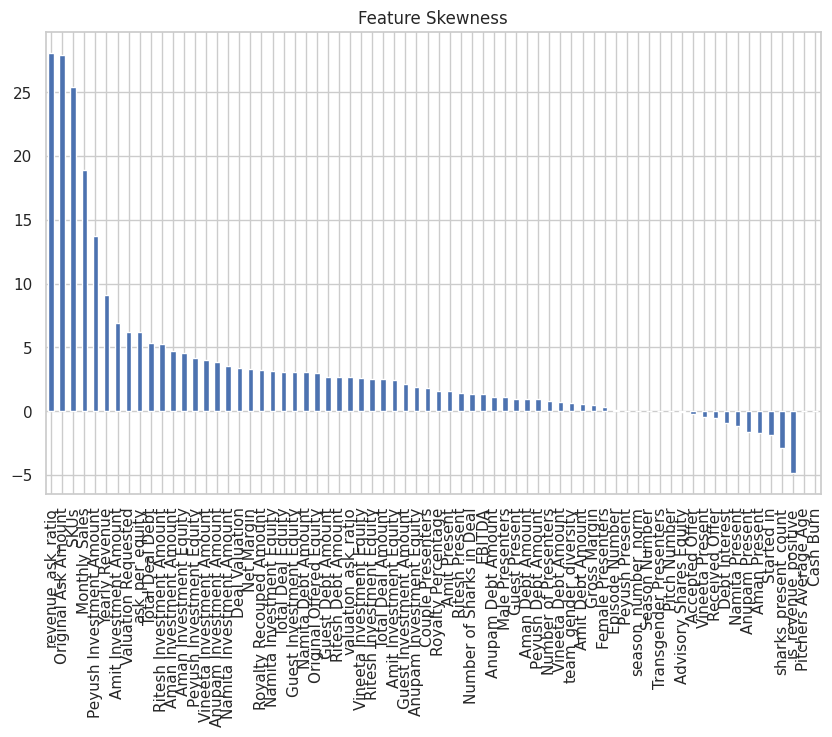

In [ ]:
skewness = df[numeric_cols].skew().sort_values(ascending=False)

plt.figure(figsize=(10,6))
skewness.plot(kind='bar')
plt.title("Feature Skewness")
plt.show()

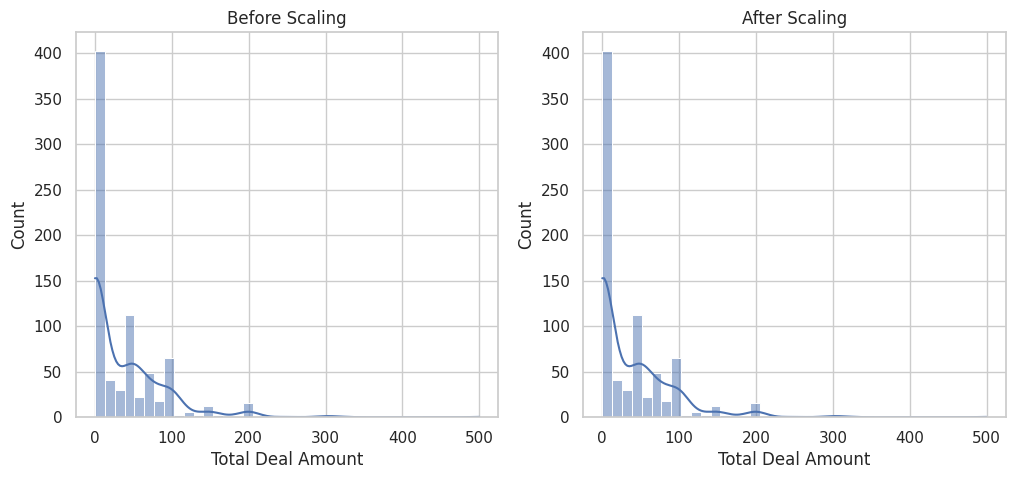

In [ ]:
col = 'Total Deal Amount'  # example

fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.histplot(df[col], kde=True, ax=axes[0])
axes[0].set_title("Before Scaling")

sns.histplot(X_scaled[col], kde=True, ax=axes[1])
axes[1].set_title("After Scaling")

plt.show()

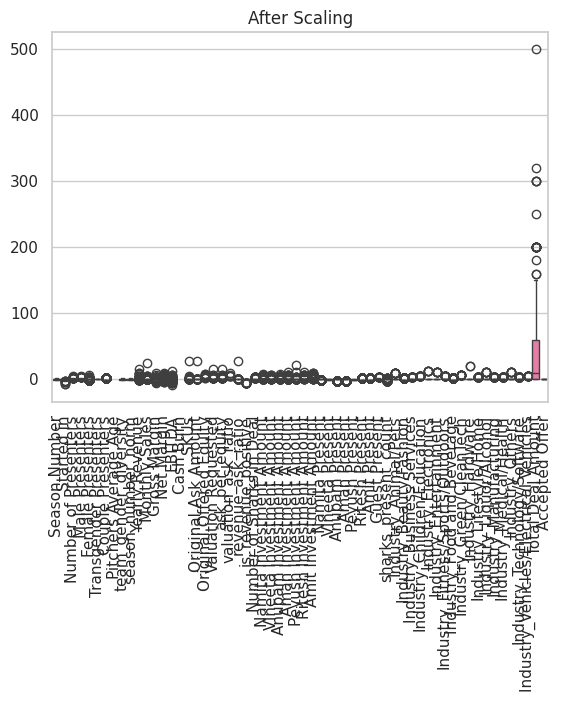

In [ ]:
sns.boxplot(data=X_scaled)
plt.xticks(rotation=90)
plt.title("After Scaling")
plt.show()

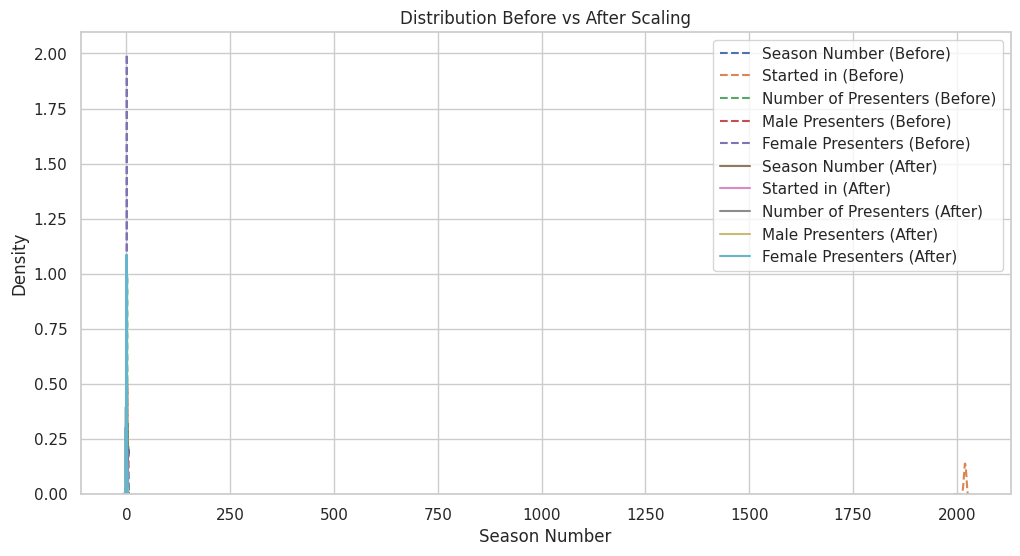

In [ ]:
plt.figure(figsize=(12,6))

common_cols = [col for col in numeric_cols if col in X_scaled.columns]

for col in common_cols[:5]:
    sns.kdeplot(df[col], label=f'{col} (Before)', linestyle='--')

for col in common_cols[:5]:
    sns.kdeplot(X_scaled[col], label=f'{col} (After)')

plt.legend()
plt.title("Distribution Before vs After Scaling")
plt.show()